# K-Means

## Source Code

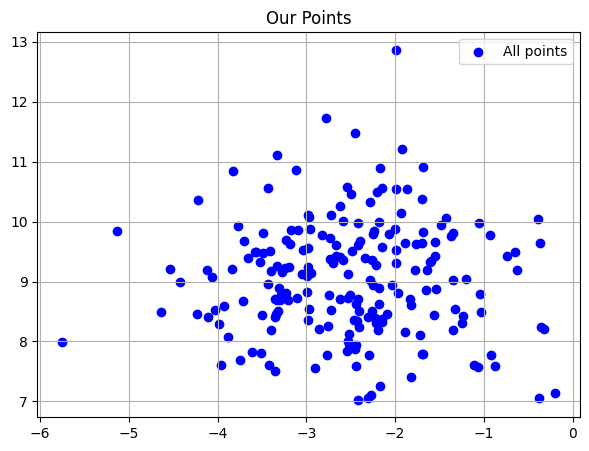

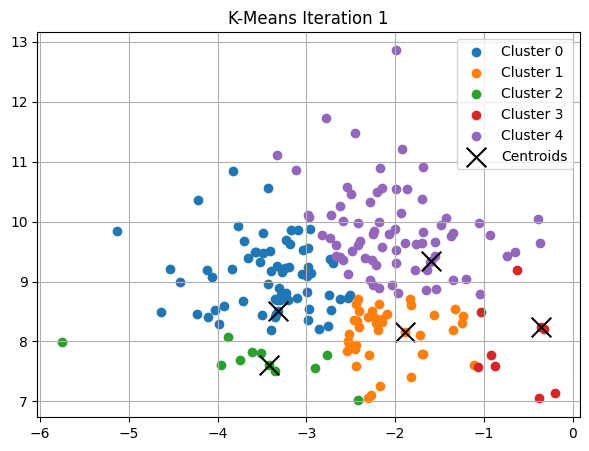

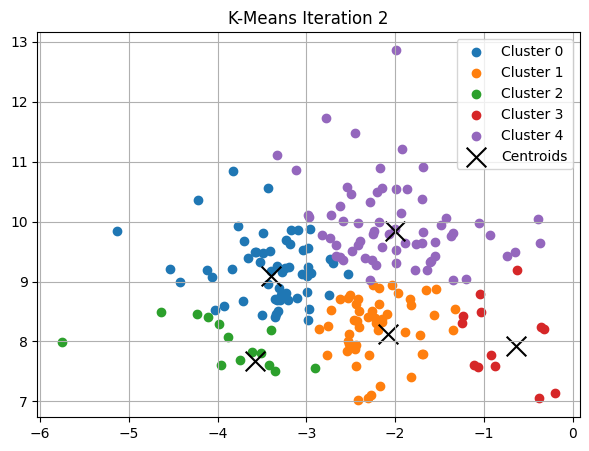

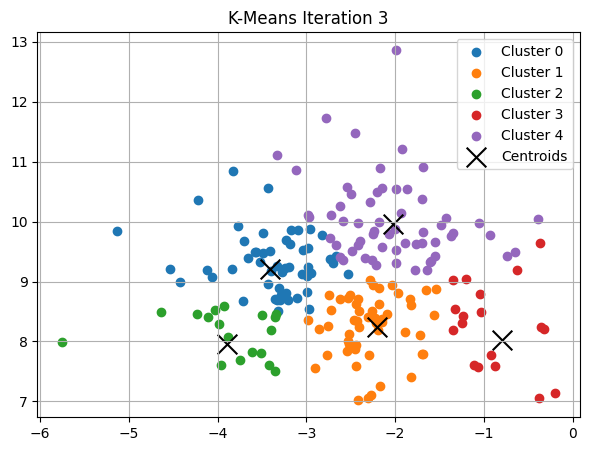

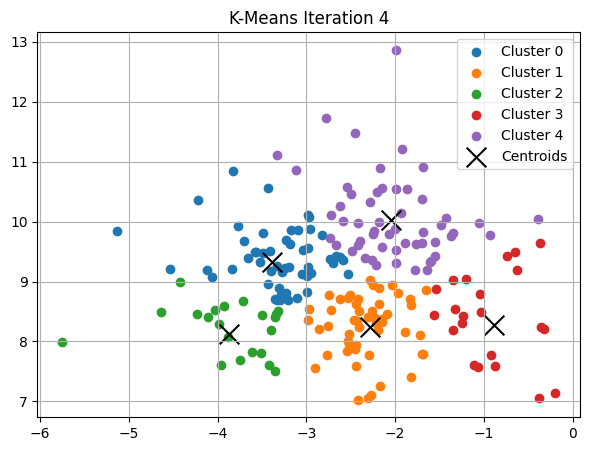

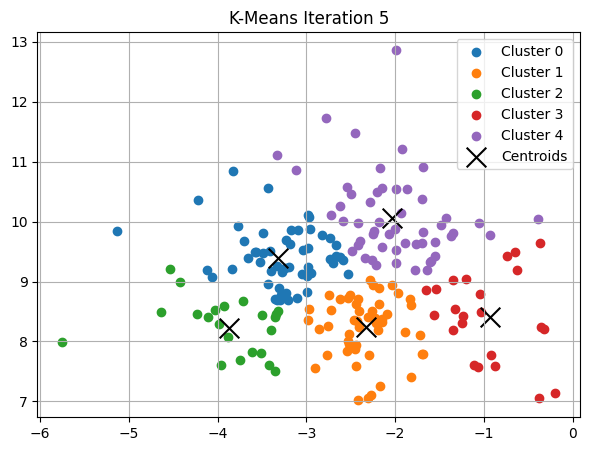

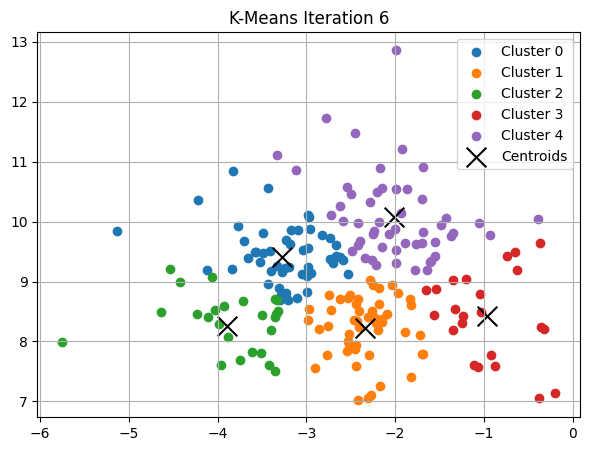

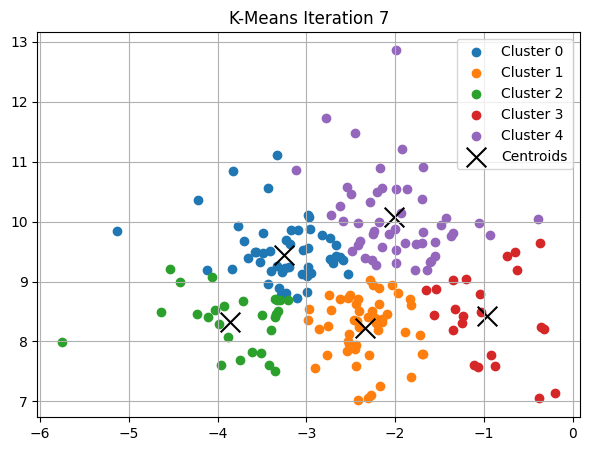

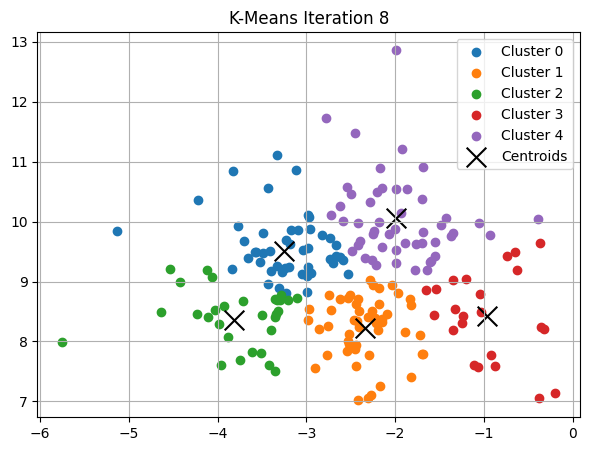

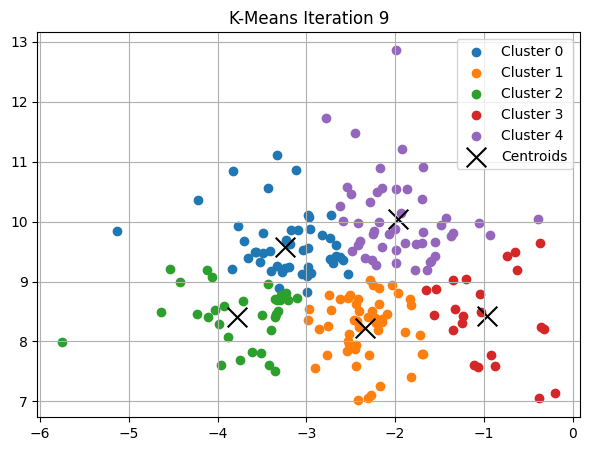

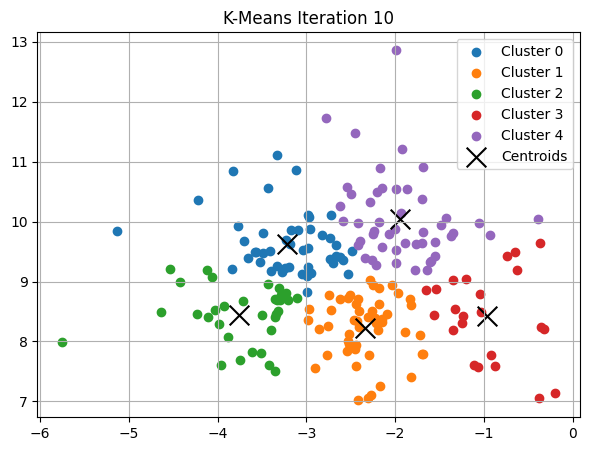

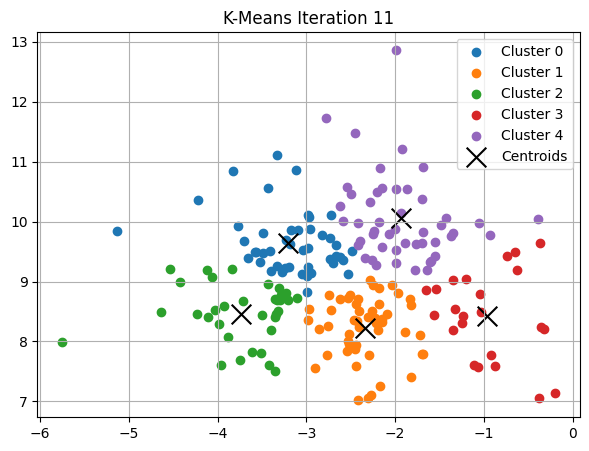

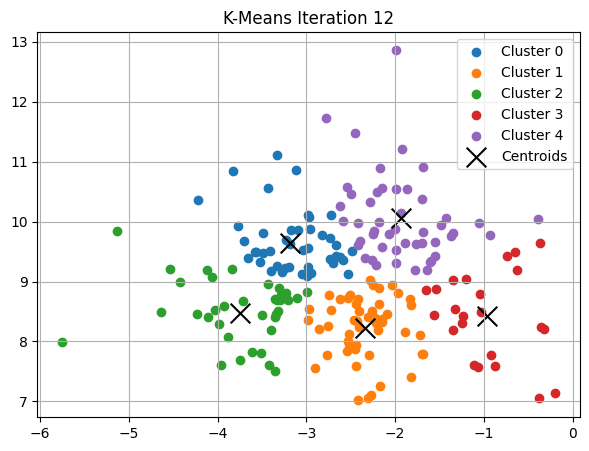

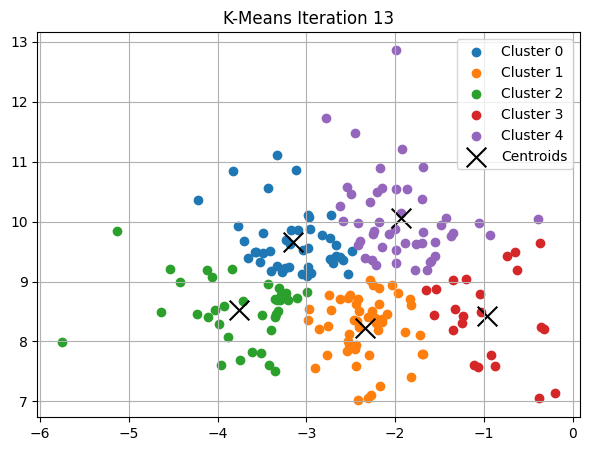

Converged at iteration 13


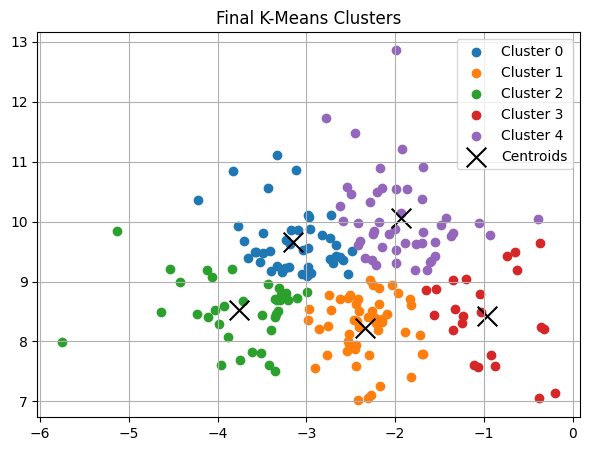

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, y_true = make_blobs(n_samples=200, centers=1 , random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c='blue', label="All points")
plt.title("Our Points")
plt.legend()
plt.grid(True)
plt.show()

k = 5
np.random.seed(42)
initial_centroid_indices = np.random.choice(len(X), k, replace=False)
centroids = X[initial_centroid_indices]

def compute_distances(X, centroids):
    return np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)


for iteration in range(20):
    distances = compute_distances(X, centroids)
    cluster_labels = np.argmin(distances, axis=1)
    new_centroids = np.array([X[cluster_labels == i].mean(axis=0) for i in range(k)])
    plt.figure(figsize=(7, 5))
    for i in range(k):
        plt.scatter(X[cluster_labels == i][:, 0], X[cluster_labels == i][:, 1], label=f"Cluster {i}")
    plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='x', s=200, label='Centroids')


    plt.title(f"K-Means Iteration {iteration + 1}")
    plt.legend()
    plt.grid(True)
    plt.show()

    if np.allclose(centroids, new_centroids):
      print(f"Converged at iteration {iteration + 1}")
      break

    centroids = new_centroids


plt.figure(figsize=(7, 5))
for i in range(k):
    plt.scatter(X[cluster_labels == i][:, 0], X[cluster_labels == i][:, 1], label=f"Cluster {i}")
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='x', s=200, label='Centroids')
plt.title("Final K-Means Clusters")
plt.legend()
plt.grid(True)
plt.show()

-----------------------------------------

## Elbow Method

👉 Idea: **How does the clustering error change when we increase k?**

* For each k (e.g. 1 → 10), run K-Means.
* Compute the **inertia** (or within-cluster sum of squared distances, WCSS):

  $$
  WCSS = \sum_{clusters} \sum_{points \in cluster} \|point - centroid\|^2
  $$
* Plot **k vs WCSS**.

✅ At first, WCSS decreases quickly as k increases (clusters fit better).
✅ After some point, the improvement slows down → curve looks like an **elbow**.
 The “elbow” is the best k.

- **Example**:
If the graph drops a lot until k=3 and then flattens, we pick k=3.Interprétation de l’inertie OR WCSS  en K-Means

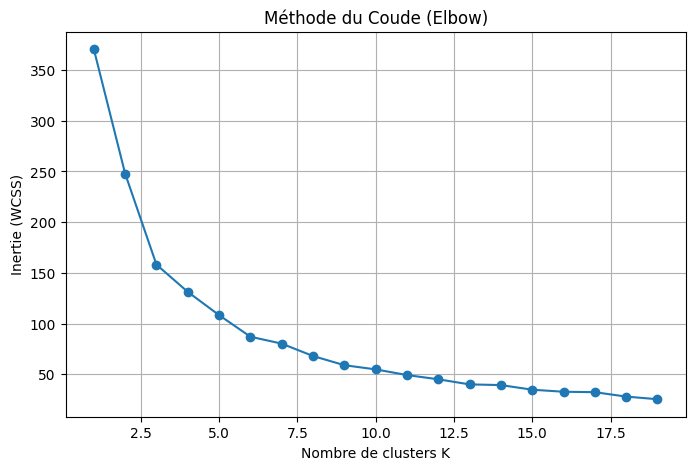

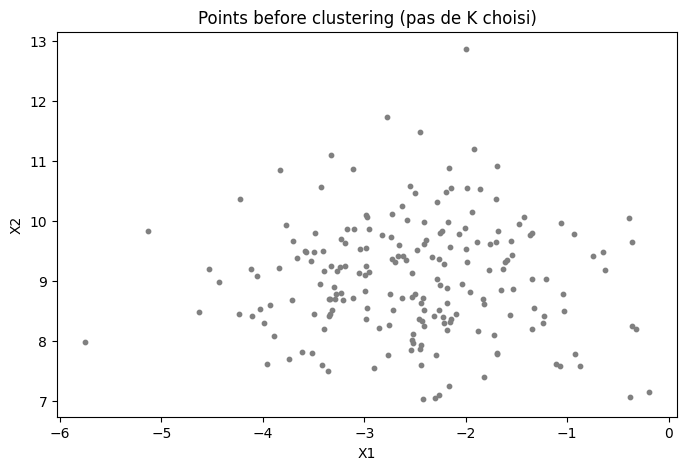

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 1. Generate synthetic data
X, _ = make_blobs(n_samples=200, centers=1, cluster_std=1, random_state=42)

# 2. Elbow method
inertia = []
K_range = range(1, 20)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Méthode du Coude (Elbow)")
plt.xlabel("Nombre de clusters K")
plt.ylabel("Inertie (WCSS)")
plt.grid(True)
plt.show()

# ---- Before choosing K ----
plt.figure(figsize=(8,5))
plt.scatter(X[:, 0], X[:, 1], s=10, c='gray')
plt.title("Points before clustering (pas de K choisi)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()



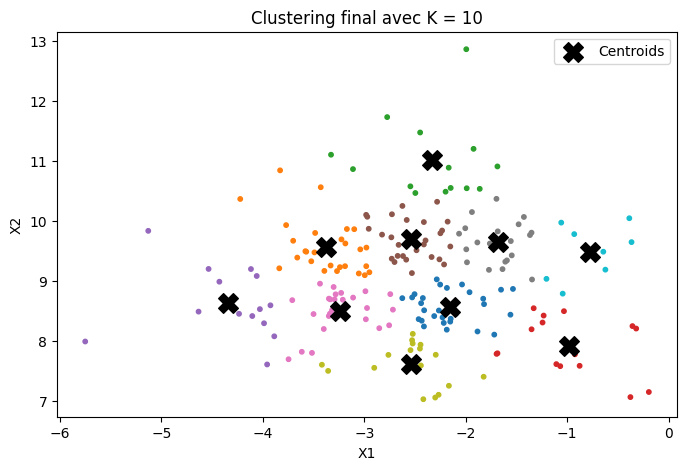

In [ ]:
# ---- After choosing K (we can choose say K=10 from elbow) ----

optimal_k = 10
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
y_kmeans = kmeans_final.fit_predict(X)

plt.figure(figsize=(8,5))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=10, cmap='tab10')
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            s=200, c='black', marker='X', label='Centroids')
plt.title(f"Clustering final avec K = {optimal_k}")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

---

## Silhouette Score

👉 Idea: **How well are the clusters separated and cohesive?**

For each point:

* Compute **a = average distance to points in the same cluster**.
* Compute **b = average distance to points in the nearest other cluster**.
* Silhouette for that point:

  $$
  s = \frac{b - a}{\max(a, b)}
  $$

  * Close to **1** → well clustered (far from other clusters, close to own cluster).
  * Close to **0** → point is on the boundary between clusters.
  * Negative → point might be in the wrong cluster.


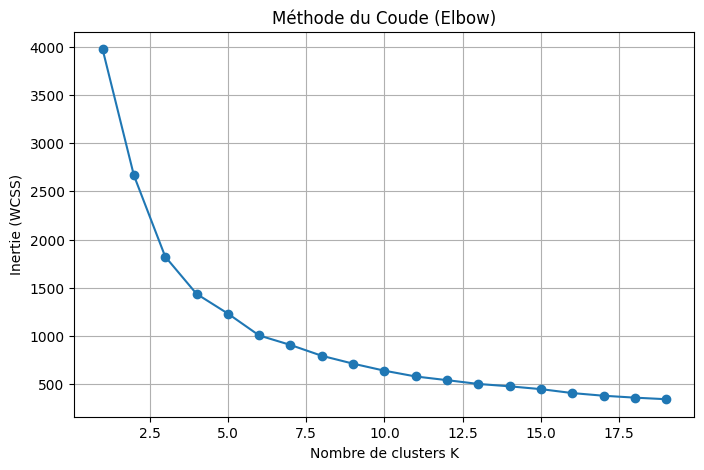

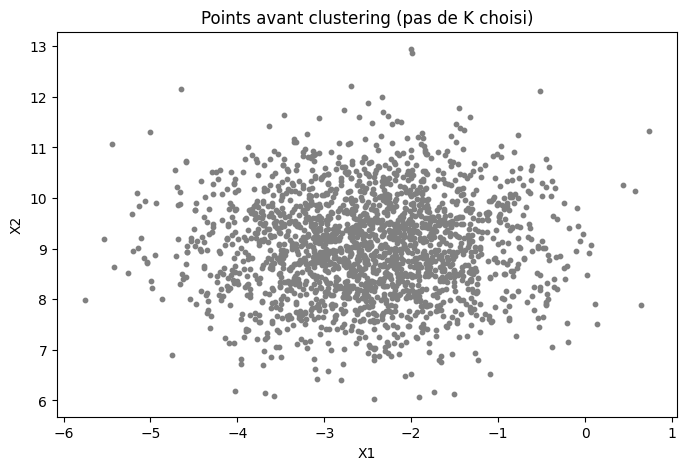

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# -------------------------------
# 1. Génération de données
# -------------------------------

X, _ = make_blobs(n_samples=2000, centers=1, cluster_std=1, random_state=42)

# -------------------------------
# 2. Méthode du Coude (Elbow)
# -------------------------------

inertia = []
K_range = range(1, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Méthode du Coude (Elbow)")
plt.xlabel("Nombre de clusters K")
plt.ylabel("Inertie (WCSS)")
plt.grid(True)
plt.show()

# -------------------------------
# 3. Score de Silhouette
# -------------------------------

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)

# -------------------------------
# 4. Visualisation : avant / après clustering
# -------------------------------

# Avant clustering
plt.figure(figsize=(8,5))
plt.scatter(X[:, 0], X[:, 1], s=10, c='gray')
plt.title("Points avant clustering (pas de K choisi)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()



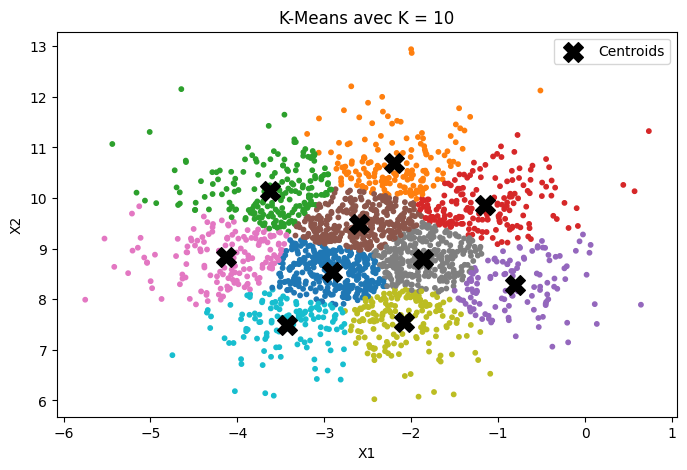

Silhouette Score: 0.31575894588855113


In [ ]:
# After clustering (choix de K optimal)

k_optimal = 10
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42)
labels = kmeans_final.fit_predict(X)


plt.figure(figsize=(8,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='tab10', s=10)
plt.scatter(kmeans_final.cluster_centers_[:,0],
            kmeans_final.cluster_centers_[:,1],
            c='black', s=200, marker='X', label="Centroids")
plt.title(f"K-Means avec K = {k_optimal}")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()


print(f"Silhouette Score: {silhouette_score(X, labels)}")

# Agglomerative Clustering

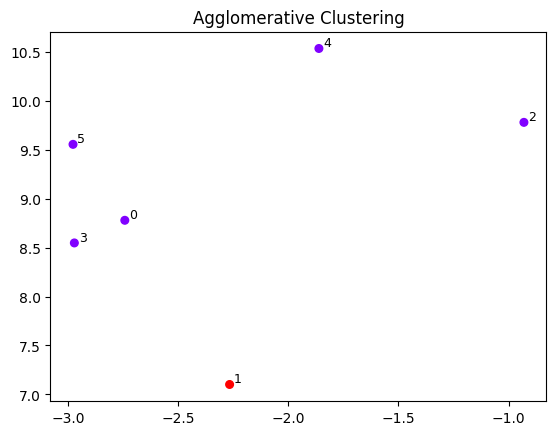

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.cluster.hierarchy as sch


# 1. Generate synthetic data
X, _ = make_blobs(n_samples=6, centers=1, cluster_std=0.8, random_state=42)

# 2. Apply Agglomerative Clustering
agg = AgglomerativeClustering(linkage = 'single')
labels = agg.fit_predict(X)


# 3. Plot clustering result
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow', s=30)
for i, (x, y) in enumerate(X):
    plt.text(x + 0.02, y + 0.02, str(i), fontsize=9)

plt.title("Agglomerative Clustering")
plt.show()


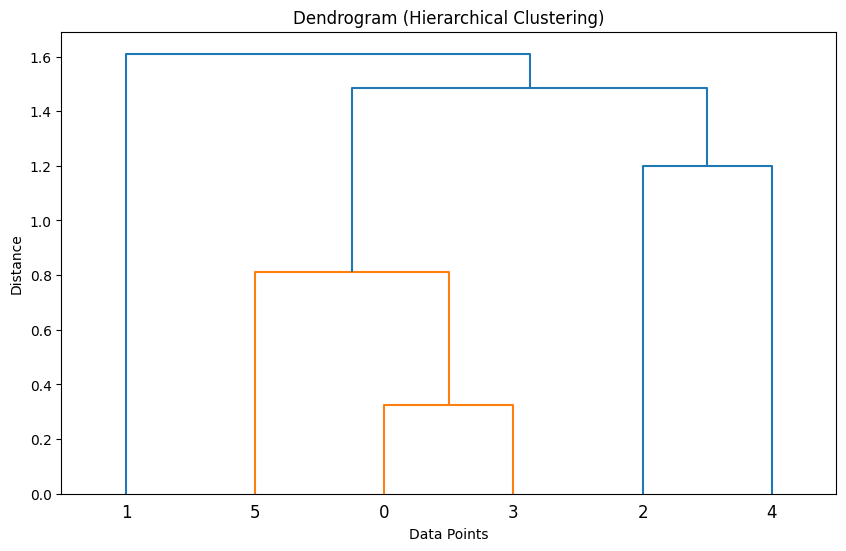

In [ ]:
# Compute linkage matrix
linkage_matrix = sch.linkage(X, method='single')

# Plot dendrogram
plt.figure(figsize=(10, 6))
sch.dendrogram(linkage_matrix)
plt.title("Dendrogram (Hierarchical Clustering)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

# DBSCAN


- Unlike KMeans or hierarchical clustering, DBSCAN does not assume a fixed number of clusters.
- It groups points based on density of neighbors, and can detect arbitrary shapes + outliers.

🔑 Key Parameters

- eps (ε) → maximum radius of the neighborhood.
→ defines how close points must be to be considered "neighbors".

- min_samples → minimum number of points required to form a dense region or cluster.

Core Concepts

- DBSCAN classifies points into three categories:

-- Core point:

Has at least min_samples neighbors within radius eps , it represents the "heart" of a dense region.

-- Border point:

Has fewer than min_samples neighbors, but is within eps of a core point.

It belongs to a cluster but is not a core itself.

-- Noise (outlier):

Not a core point, and not within eps of any core point.

Labeled as -1 in sklearn.

**- Algorithm Steps**

- Pick an unvisited point.

- If it has at least min_samples points within eps → mark as core point and create a new cluster.

- Expand the cluster:
  - Add all density-reachable points (core + border).
  - If neighbors are also core points, keep expanding.
  - If a point is not density-reachable → mark it as noise.

- Repeat until all points are visited.

📊 Example (eps=0.5, min_samples=5)

Imagine points in 2D space:

Dense regions → many points close together → form clusters.

Sparse regions → isolated points → marked as noise.

- So DBSCAN says:

"If you are surrounded by enough friends (≥ min_samples) in a small radius (eps), you form a group (cluster). Otherwise, you are just a loner (outlier)."

DBSCAN silhouette score: 0.918
DBSCAN found 3 clusters and 9 outliers


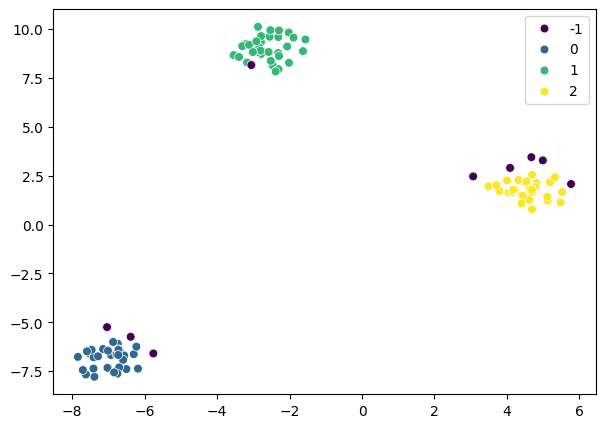

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# =========================================================
# 1. Generate synthetic data
# =========================================================

X, _ = make_blobs(n_samples=100, cluster_std=0.6, random_state=42)

# =========================================================
# 2. Apply DBSCAN
# =========================================================

dbscan = DBSCAN(min_samples=4, eps=0.5)
db_labels = dbscan.fit_predict(X)

# Calculate silhouette score (excluding noise points -1)

valid_labels = db_labels[db_labels != -1]
if len(set(valid_labels)) > 1:  # need at least 2 clusters
    db_silhouette_score = silhouette_score(X[db_labels != -1], valid_labels)
    print(f"DBSCAN silhouette score: {db_silhouette_score:.3f}")
else:
    print("DBSCAN did not create valid clusters for silhouette scoring.")

# Show DBSCAN results

clusters_dbscan = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f"DBSCAN found {clusters_dbscan} clusters and {Counter(db_labels)[-1]} outliers")

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=db_labels, palette='viridis', s=40)
plt.show()


--------------------------------

🔹 What is the Iris dataset?

It’s a classic dataset in machine learning that contains measurements of iris flowers. It’s often used for classification tasks.

150 samples (rows)

4 features (columns):

- sepal length (cm)

- sepal width (cm)

- petal length (cm)

- petal width (cm)

Target: species of iris (3 classes)

0 → Setosa

1 → Versicolor

2 → Virginica

# TP IRIS DATASET

In [ ]:
!pip install kneed

Optimal number of clusters (Elbow point): 6


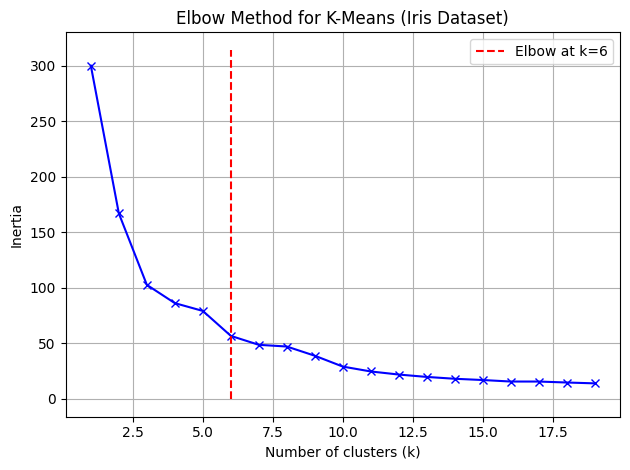

Silhouette Scores:
K-Means : 0.343
Agglomerative: 0.361
DBSCAN (eps=0.3, min_samples=4): 0.433


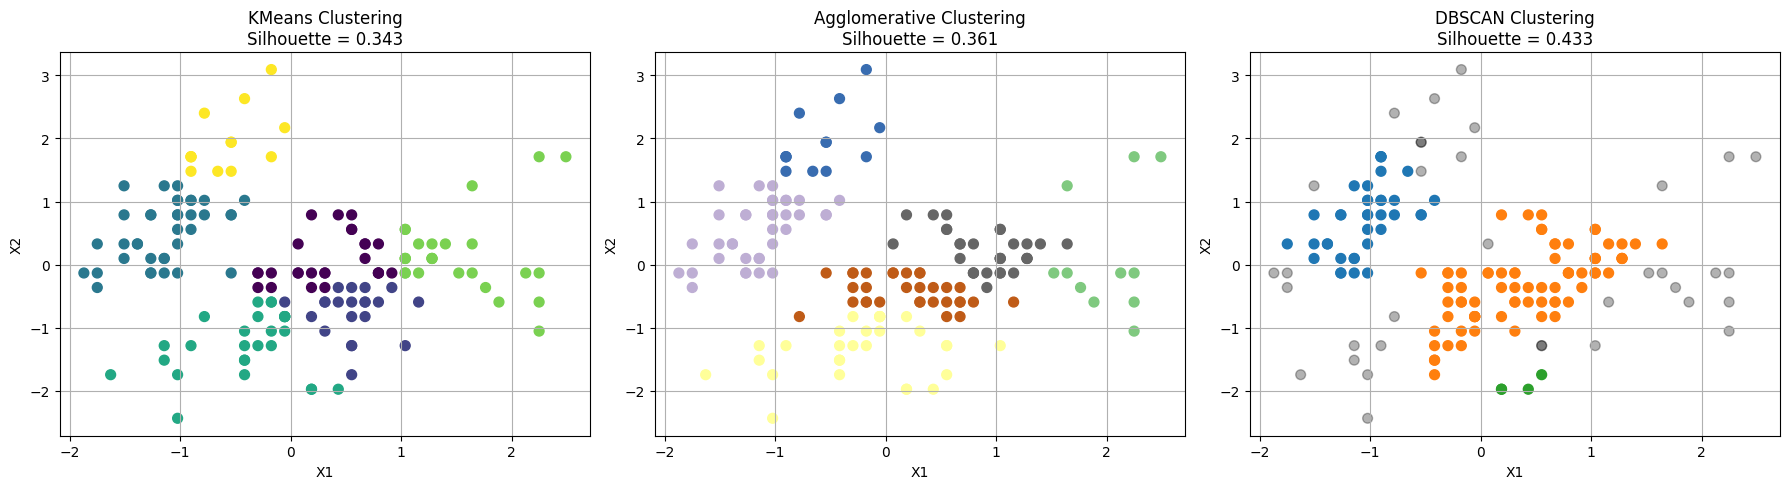

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator

iris = load_iris()
X = iris.data[:, :2]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
inertias = []
k_values = range(1, 20)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# KneeLocator to find the "elbow"

kn = KneeLocator(k_values, inertias, curve="convex", direction="decreasing")
best_k = kn.knee
print(f"Optimal number of clusters (Elbow point): {best_k}")

# Plot Elbow Curve with knee

plt.figure()
plt.plot(k_values, inertias, 'bx-')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means (Iris Dataset)")
plt.vlines(best_k, plt.ylim()[0], plt.ylim()[1], linestyles="dashed", colors="red", label=f"Elbow at k={best_k}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# For all algorithms calculate silhouette score
# KMeans with k=12
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_score = silhouette_score(X_scaled, kmeans_labels)

# Agglomerative Clustering with n=12
agglo = AgglomerativeClustering(n_clusters=6)
agglo_labels = agglo.fit_predict(X_scaled)
agglo_score = silhouette_score(X_scaled, agglo_labels)

# DBSCAN with adjusted parameters

dbscan = DBSCAN(eps=0.3, min_samples=4)
dbscan_labels = dbscan.fit_predict(X_scaled)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
if n_clusters_dbscan >= 2:
    mask = dbscan_labels != -1
    dbscan_score = silhouette_score(X_scaled[mask], dbscan_labels[mask])
else:
    dbscan_score = None

# Display results in console

print("Silhouette Scores:")
print(f"K-Means : {kmeans_score:.3f}")
print(f"Agglomerative: {agglo_score:.3f}")
print(f"DBSCAN (eps=0.3, min_samples=4): {dbscan_score:.3f}" if dbscan_score else "DBSCAN did not find enough clusters.")

# Plotting with silhouette scores in titles

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# KMeans Plot

axs[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, cmap='viridis', s=50)
axs[0].set_title(f"KMeans Clustering\nSilhouette = {kmeans_score:.3f}")

# Agglomerative Plot

axs[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=agglo_labels, cmap='Accent', s=50)
axs[1].set_title(f"Agglomerative Clustering\nSilhouette = {agglo_score:.3f}")

# DBSCAN Plot


colors = [plt.cm.tab10(lbl) if lbl != -1 else (0, 0, 0, 0.3) for lbl in dbscan_labels]

axs[2].scatter(X_scaled[:, 0], X_scaled[:, 1], c=colors, s=50)

title = (f"DBSCAN Clustering\nSilhouette = {dbscan_score:.3f}"
         if dbscan_score else "DBSCAN Clustering\nNot enough clusters")
axs[2].set_title(title)

for ax in axs:
    ax.set(xlabel="X1", ylabel="X2")
    ax.grid(True)


plt.tight_layout()
plt.show()


Variance expliquée par les 2 composants : 95.81%
Nombre optimal de clusters (Elbow): 3
------------------------------
Score Silhouette K-Means: 0.509
Score Silhouette Agglomerative: 0.511
Score Silhouette DBSCAN: 0.6639421711766671


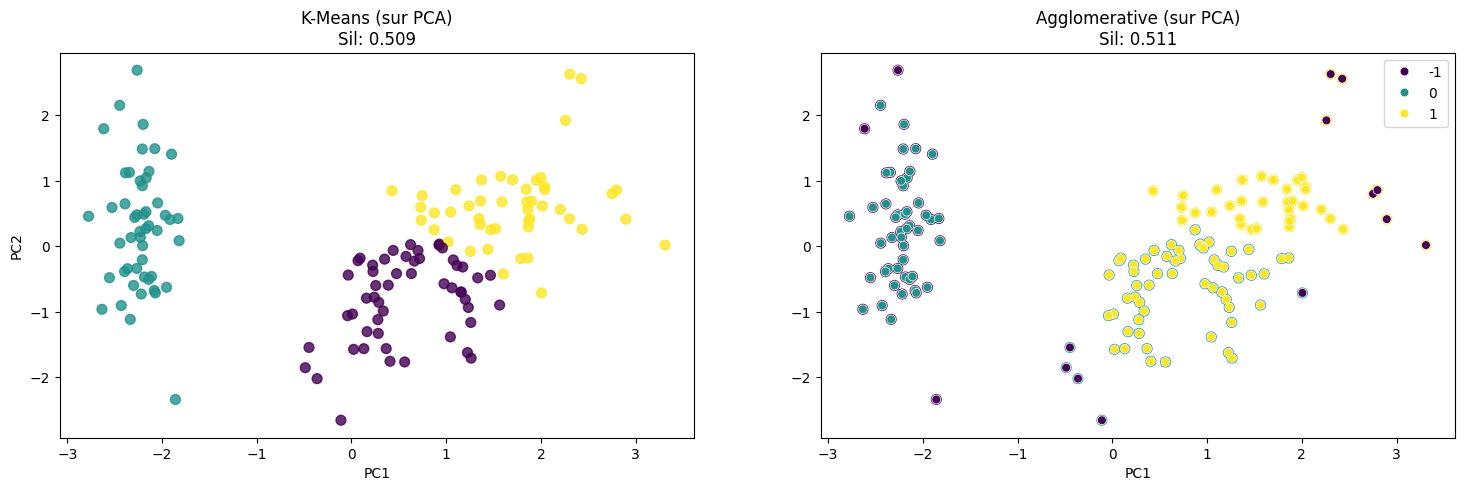

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from kneed import KneeLocator

# 1. Chargement de TOUTES les données (4 colonnes)
iris = load_iris()
X = iris.data  # On prend tout, pas juste [:, :2]

# 2. Scaling (Important pour le PCA et le Clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance expliquée par les 2 composants : {np.sum(pca.explained_variance_ratio_):.2%}")

# --- À partir d'ici, on utilise X_pca pour le clustering et l'affichage ---

# Elbow Method sur les données PCA
inertias = []
k_values = range(1, 15)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)

# Trouver le coude
kn = KneeLocator(k_values, inertias, curve="convex", direction="decreasing")
best_k = kn.knee if kn.knee else 3 # Fallback si kneed ne trouve pas
print(f"Nombre optimal de clusters (Elbow): {best_k}")

# --- Clustering ---

# 1. K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # On sait qu'il y a 3 iris, testons 3
kmeans_labels = kmeans.fit_predict(X_pca)
kmeans_score = silhouette_score(X_pca, kmeans_labels)

# 2. Agglomerative
agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels = agglo.fit_predict(X_pca)
agglo_score = silhouette_score(X_pca, agglo_labels)

# 3. DBSCAN
# Note : Les distances changent après PCA, on ajuste eps
dbscan = DBSCAN(eps=0.4, min_samples=4)
dbscan_labels = dbscan.fit_predict(X_pca)

# Calcul score DBSCAN (en ignorant le bruit -1)
if len(set(dbscan_labels)) > 1:
    mask = dbscan_labels != -1
    if np.sum(mask) > 0: # S'il reste des points non-bruit
        dbscan_score = silhouette_score(X_pca[mask], dbscan_labels[mask])
    else:
        dbscan_score = -1
else:
    dbscan_score = None

# --- Affichage ---
print("-" * 30)
print(f"Score Silhouette K-Means: {kmeans_score:.3f}")
print(f"Score Silhouette Agglomerative: {agglo_score:.3f}")
print(f"Score Silhouette DBSCAN: {dbscan_score if dbscan_score else 'N/A'}")

fig, axs = plt.subplots(1, 2, figsize=(18, 5))

# Plot K-Means
axs[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=50, alpha=0.8)
axs[0].set_title(f"K-Means (sur PCA)\nSil: {kmeans_score:.3f}")
axs[0].set_xlabel("PC1")
axs[0].set_ylabel("PC2")

# Plot Agglomerative
axs[1].scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels, cmap='viridis', s=50, alpha=0.8)
axs[1].set_title(f"Agglomerative (sur PCA)\nSil: {agglo_score:.3f}")
axs[1].set_xlabel("PC1")


plt.show()


<Axes: >

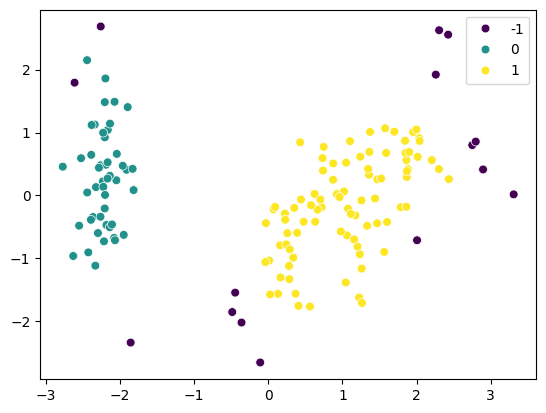

In [ ]:
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_labels, palette='viridis', s=40)